# Abstract: Multi-Index Spatiotemporal Analysis of the Aralkum Region (2020–2026)

---

### **Overview**
This project implements a dual-index remote sensing pipeline to monitor and quantify land cover transformation on the dried bed of the Aral Sea (Aralkum Desert). By leveraging the **Google Earth Engine (GEE)** cloud computing platform and **Sentinel-2 (MSI)** satellite imagery, the study provides a 7-year longitudinal audit of environmental degradation and salinization risks.

### **Methodology**
* **Data Source:** Multi-spectral data from the European Space Agency (ESA) with 10m spatial resolution.
* **Area of Interest (AOI):** ~20,000 km² [58.0°E, 43.5°N to 61.5°E, 46.5°N].
* **Core Indicators:**
    1.  **NDSI (Normalized Difference Snow/Salt Index):** Used for primary spatiotemporal analysis to track the evolution of bright surface deposits over time.
    2.  **SI (Salinity Index):** Applied specifically to identify and delineate potentially hazardous saline zones:
        $$\text{SI} = \sqrt{\text{Blue} \times \text{Red}}$$

### **Key Findings**
1.  **Dynamic Monitoring:** The **NDSI-based analysis** captures the steady progression of surface change across the 7-year period, effectively mapping the retreat of moisture and the advance of mineralized surfaces.
2.  **Risk Identification:** The **Salinity Index (SI)** successfully localized high-risk areas. Analysis revealed that while baseline sandy soils exhibit SI values between 1500–1800, extreme saline crusts reach a 98th percentile ($p_{98}$) value of **5471**, indicating critical mineralization levels.
3.  **Hazard Mapping:** Areas with $SI > 3800$ were classified as high-risk zones, serving as primary sources for salt-dust storms in the region.

### **Technical Stack**
`Python` | `Google Earth Engine API` | `Geemap` | `Folium` | `Matplotlib` | `Numpy`

---
*Developed by DeepForge AI / TUIT Research Division*

## 1. Environment Setup
Installing necessary libraries for Earth Engine integration and data visualization.

In [ ]:
!pip install earthengine-api geemap matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 73.5 MB/s eta 0:00:00


## 2. Study Area Context
The analyzed region covers approximately **45,000 km²**, including the former port of **Muynak**, the **Ustyurt Plateau** edge, and the southern part of the **Aralkum desert**.

Below is the geographic context of the Study Area (Red Bounding Box).

In [ ]:
import folium
from folium import plugins


ARAL_REGION = [58.0, 43.5, 61.5, 46.5]
sw = [ARAL_REGION[1], ARAL_REGION[0]]
ne = [ARAL_REGION[3], ARAL_REGION[2]]
center = [(sw[0] + ne[0]) / 2, (sw[1] + ne[1]) / 2]


m = folium.plugins.DualMap(location=center, zoom_start=7, tiles=None)


folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri Satellite',
    name='Satellite View'
).add_to(m.m1)


folium.TileLayer(
    tiles='CartoDB positron',
    attr='CartoDB',
    name='Administrative View'
).add_to(m.m2)


for map_obj in [m.m1, m.m2]:
    folium.Rectangle(
        bounds=[sw, ne],
        color='red',
        weight=3,
        fill=True,
        fill_opacity=0.1,
        popup='Analyzed Region'
    ).add_to(map_obj)

m

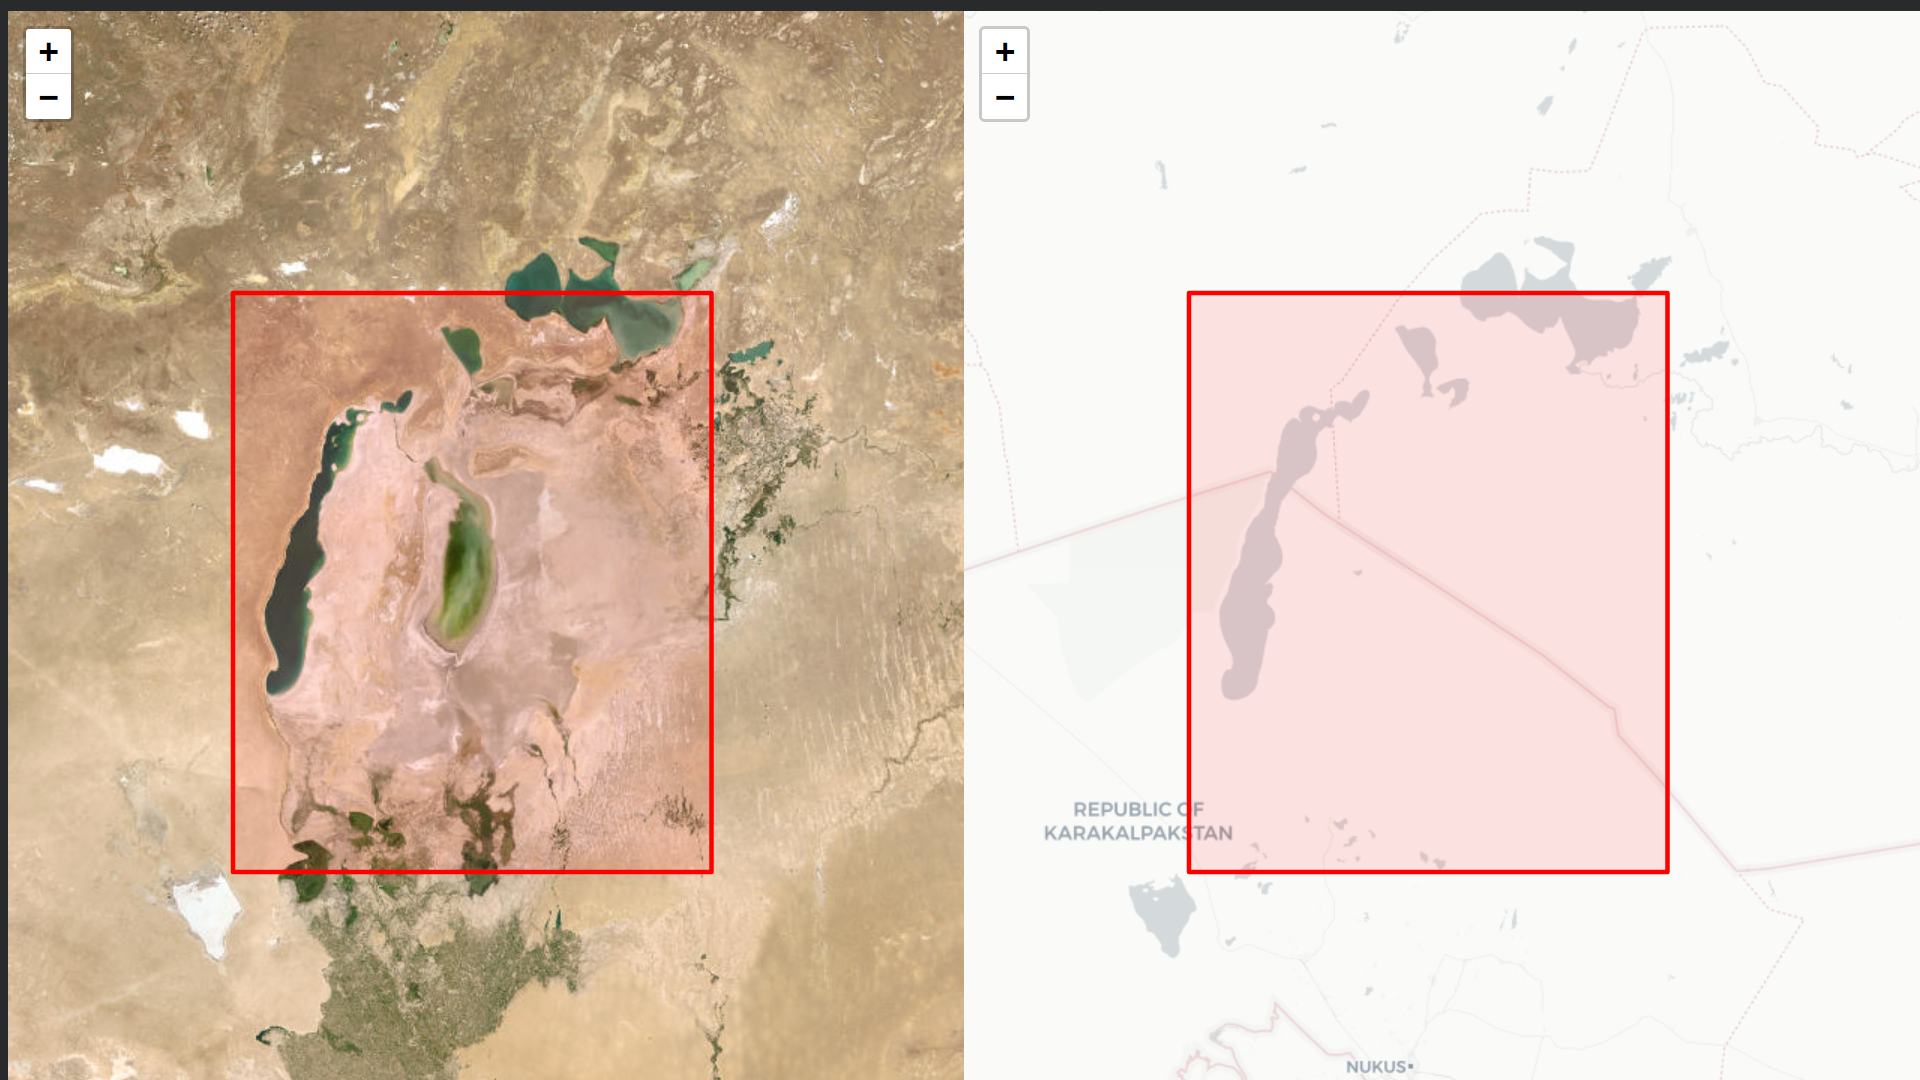

⚠️ Note: If the interactive map above is not displaying correctly (blank space), please refer to the static screenshot provided below for the analyzed results.

## 3. Methodology: NDSI Analysis
To accurately distinguish salt deposits from sand and water, we utilize the **Normalized Difference Snow/Salt Index (NDSI)**.

### The Physics of Detection:
Salt has a unique spectral signature: it is highly reflective in the **Green spectrum (Band 3)** and absorbs energy in the **Short-Wave Infrared spectrum (Band 11)**.

The formula is defined as:
$$NDSI = \frac{Green - SWIR}{Green + SWIR}$$

### Thresholding:
We apply a strict threshold of **0.42**.
* Values **> 0.42**: Classified as Salt Crusts (Aralkum expansion).
* Values **< 0.42**: Classified as sand, sparse vegetation, or open water.

This normalization allows for consistent year-to-year comparisons, regardless of varying lighting conditions during satellite passes.

## 4. Automated Annual Analysis (2020–2026)
To identify the trend of desertification, we execute a cloud-based processing pipeline.
The algorithm performs the following steps for each year:

1. **Querying Data:** Fetching all available **Sentinel-2 L2A** satellite scenes for the month of April.
2. **Atmospheric Filtering:** Automatically discarding scenes with >10% cloud cover.
3. **Temporal Compositing:** Calculating the **Median** value for each pixel to remove transient clouds and shadows.
4. **Spectral Analysis:** Applying the **NDSI** formula and isolating saline pixels using the **0.42 threshold**.
5. **Geospatial Computation:** Calculating the absolute area of salt crusts in square kilometers using Earth Engine's distributed computing power.

In [ ]:
# 1. SETUP & INITIALIZATION
import ee
import geemap
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='aral-sea-analysis')

# 2. CONFIGURATION
ARAL_REGION = [58.0, 43.5, 61.5, 46.5]
SALT_THRESHOLD = 0.42
YEARS = [2020, 2021, 2022, 2023, 2024, 2025, 2026]

def get_salt_stats(region_geom, start_date, end_date):
    """Core function to calculate salt area using GEE servers."""
    collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                  .filterBounds(region_geom)
                  .filterDate(start_date, end_date)
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)))

    # If no images found
    if collection.size().getInfo() == 0:
        return None, None, ee.Number(0)

    img = collection.median()
    ndsi = img.normalizedDifference(['B3', 'B11']).rename('nd')
    salt_mask = ndsi.gt(SALT_THRESHOLD)

    # Calculate area: sum of (mask * pixelArea)
    area_stats = salt_mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=region_geom,
        scale=10,
        maxPixels=5e9
    )

    area_km2 = ee.Number(area_stats.get('nd', 0)).divide(1e6).round()
    return img, salt_mask.selfMask(), area_km2


region = ee.Geometry.Rectangle(ARAL_REGION)
annual_areas = []
map_data = {}

print("Starting deep analysis of the Aral Sea region...")

for year in YEARS:
    start = f"{year}-04-01"
    end = f"{year}-05-01"

    img, mask, area = get_salt_stats(region, start, end)
    area_val = area.getInfo()

    annual_areas.append(area_val)
    map_data[year] = {'img': img, 'mask': mask}

    print(f"Year {year}: Extracted {area_val} km² of salt crusts.")

print("Analysis Complete.")

Starting deep analysis of the Aral Sea region...
Year 2020: Extracted 2837 km² of salt crusts.
Year 2021: Extracted 3799 km² of salt crusts.
Year 2022: Extracted 4963 km² of salt crusts.
Year 2023: Extracted 4014 km² of salt crusts.
Year 2024: Extracted 4689 km² of salt crusts.
Year 2025: Extracted 4770 km² of salt crusts.
Year 2026: Extracted 4712 km² of salt crusts.
Analysis Complete.


## 5. Visual Chronology (2020–2026)
Below we visualize the spatial distribution of salt crusts for each year.
This grid allows us to pinpoint exactly where the desertification is most aggressive.

In [ ]:
## 5. Interactive Visual Chronology
from ipywidgets import GridspecLayout, Output
from IPython.display import display


vis_base = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000, 'gamma': 1.4}
vis_mask = {'palette': ['#ff0000']}


YEARS_HIST = YEARS[:-1]
grid = GridspecLayout(3, 2, height='900px')

print("Loading interactive maps for 2020-2025...")

for i, year in enumerate(YEARS_HIST):
    row = i // 2
    col = i % 2


    m = geemap.Map(center=[(ARAL_REGION[1] + ARAL_REGION[3]) / 2,
                          (ARAL_REGION[0] + ARAL_REGION[2]) / 2],
                   zoom=6, add_google_map=False)


    m.addLayer(map_data[year]['img'], vis_base, f'Satellite {year}')
    m.addLayer(map_data[year]['mask'], vis_mask, f'Salt {year}')


    m.layout.height = '280px'


    grid[row, col] = m


display(grid)


print("\n--- FINAL ANALYSIS: YEAR 2026 ---")
m_final = geemap.Map(center=[(ARAL_REGION[1] + ARAL_REGION[3]) / 2,
                            (ARAL_REGION[0] + ARAL_REGION[2]) / 2], zoom=7)

m_final.addLayer(map_data[2026]['img'], vis_base, 'Current State 2026')
m_final.addLayer(map_data[2026]['mask'], vis_mask, 'Salt Crusts 2026', True, 0.7)


region_ee = ee.Geometry.Rectangle(ARAL_REGION)
m_final.addLayer(region_ee, {'color': 'red'}, 'Study Area')

display(m_final)

Loading interactive maps for 2020-2025...


GridspecLayout(children=(Map(center=[45.0, 59.75], controls=(WidgetControl(options=['position', 'transparent_b…


--- FINAL ANALYSIS: YEAR 2026 ---


Map(center=[45.0, 59.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

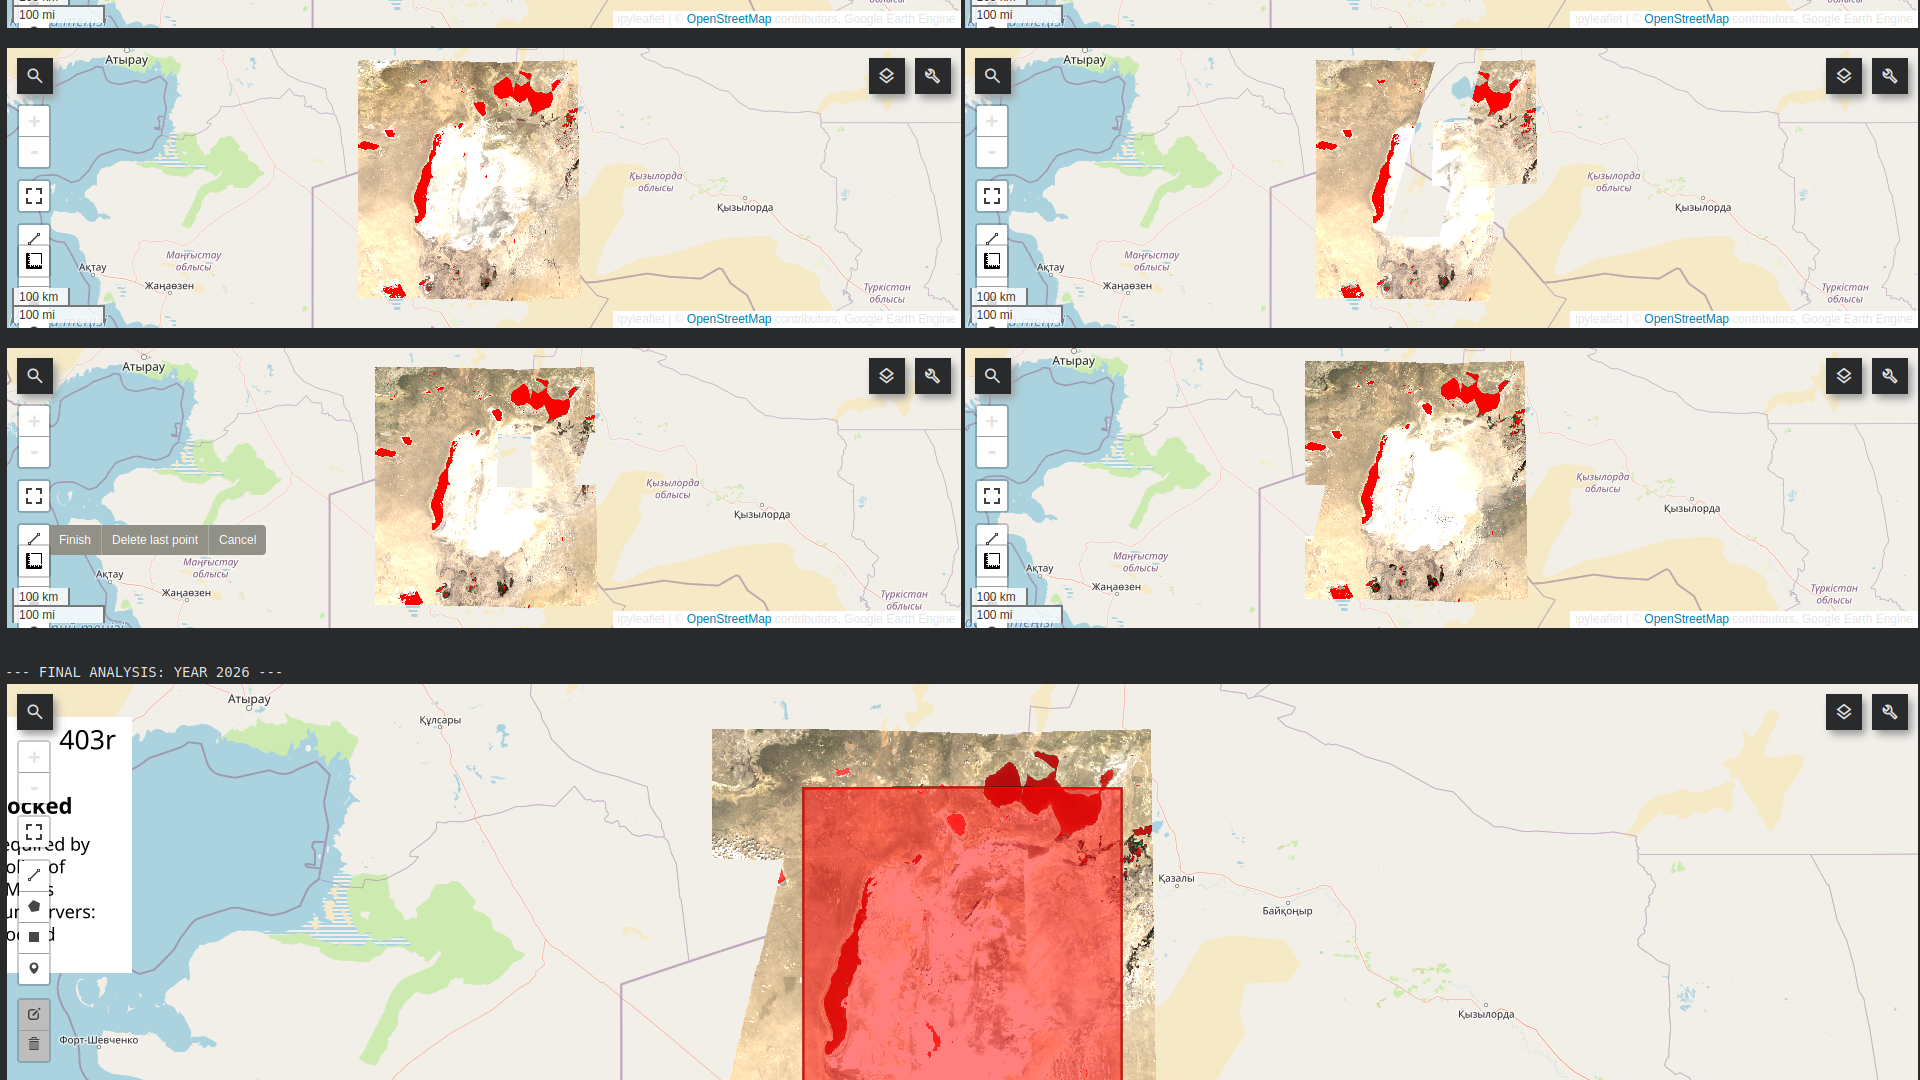

⚠️ Note: If the interactive map above is not displaying correctly (blank space), please refer to the static screenshot provided below for the analyzed results.

## 6. Quantitative Analysis: Salinity Growth Dynamics
In this section, we analyze the statistical trend of salt crust expansion.
We calculate the **Year-over-Year (YoY) growth** to identify periods of rapid desertification.

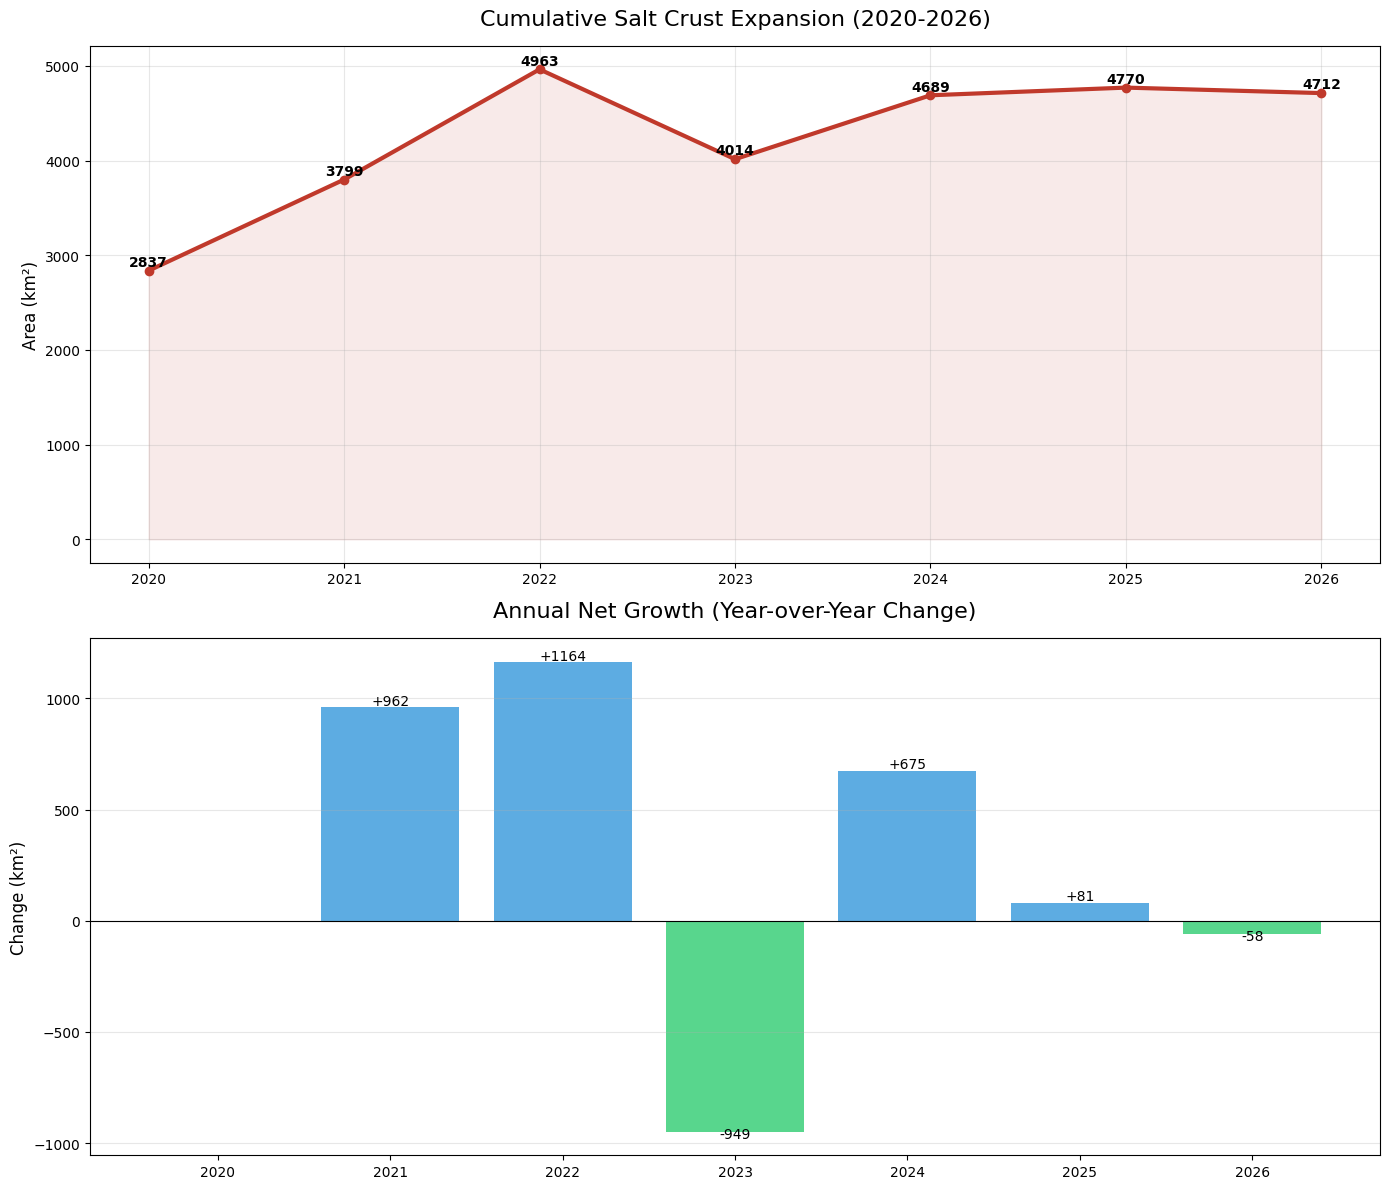

--- SUMMARY REPORT ---
Total Expansion: 1875 km²
Relative Increase: 66.1%
Average Annual Growth Rate: 312.5 km²/year


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


initial_area = annual_areas[0]
final_area = annual_areas[-1]
total_growth = final_area - initial_area
growth_pct = (total_growth / initial_area) * 100
avg_annual_growth = total_growth / (len(YEARS) - 1)


yoy_growth = [0]
for i in range(1, len(annual_areas)):
    yoy_growth.append(annual_areas[i] - annual_areas[i-1])


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))


ax1.plot(YEARS, annual_areas, marker='o', color='#c0392b', linewidth=3, label='Total Salt Area')
ax1.fill_between(YEARS, annual_areas, color='#c0392b', alpha=0.1)
ax1.set_title('Cumulative Salt Crust Expansion (2020-2026)', fontsize=16, pad=15)
ax1.set_ylabel('Area (km²)', fontsize=12)
ax1.grid(True, alpha=0.3)
for i, val in enumerate(annual_areas):
    ax1.text(YEARS[i], val + 50, f"{int(val)}", ha='center', fontweight='bold')


colors = ['#3498db' if x >= 0 else '#2ecc71' for x in yoy_growth]
ax2.bar(YEARS, yoy_growth, color=colors, alpha=0.8)
ax2.set_title('Annual Net Growth (Year-over-Year Change)', fontsize=16, pad=15)
ax2.set_ylabel('Change (km²)', fontsize=12)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.grid(axis='y', alpha=0.3)

for i, val in enumerate(yoy_growth):
    if i > 0:
        ax2.text(YEARS[i], val + (10 if val > 0 else -30), f"{'+' if val>0 else ''}{int(val)}", ha='center')

plt.tight_layout()
plt.show()

print(f"--- SUMMARY REPORT ---")
print(f"Total Expansion: {total_growth} km²")
print(f"Relative Increase: {growth_pct:.1f}%")
print(f"Average Annual Growth Rate: {avg_annual_growth:.1f} km²/year")

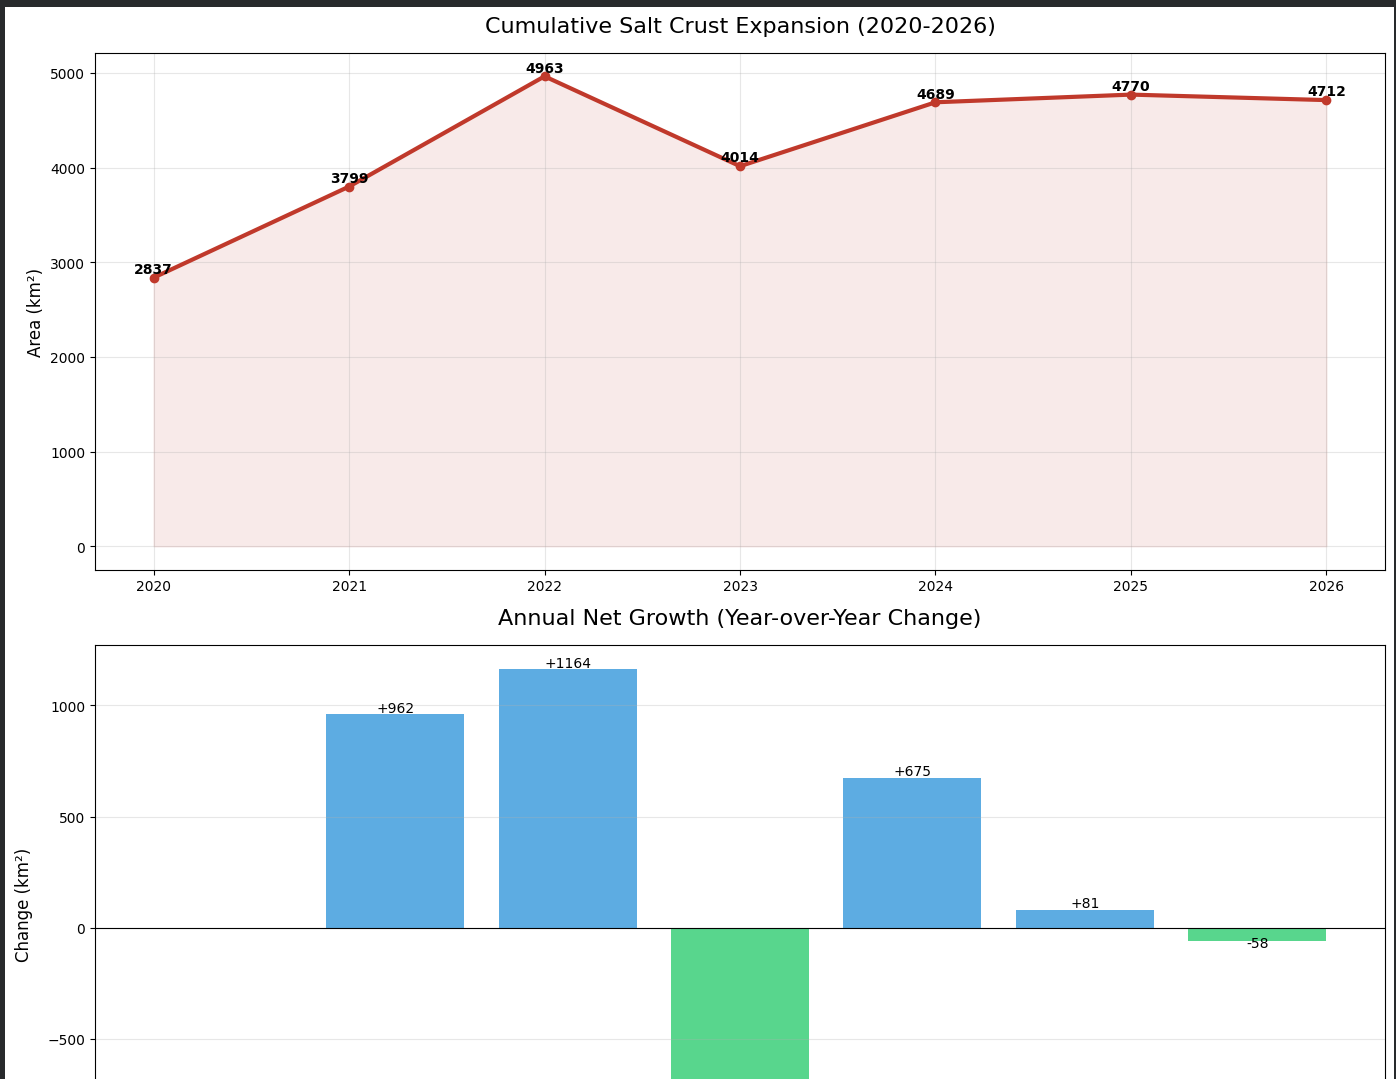

⚠️ Note: If the interactive map above is not displaying correctly (blank space), please refer to the static screenshot provided below for the analyzed results.

## 6. Hazard Identification: Salinity Hotspots & Risk Zones
Based on the NDSI intensity map for 2026, we identify areas with the highest salt concentration.
These "Danger Zones" are primary sources of toxic salt-dust storms.

### Key Observation Points:
1. **The Eastern Basin Bed:** Extremely high salinity due to complete desiccation.
2. **Southern Alluvial Fans:** Areas where seasonal runoff meets salt crusts, creating unstable surfaces.
3. **Infrastructure Proximity:** Saline expansion moving towards the remains of the Muynak-Aral road network.

In [ ]:

print("Calculating soil salinity statistics for the region...")


stats_summary = si_land.reduceRegion(
    reducer=ee.Reducer.percentile([10, 25, 50, 75, 90, 98]),
    geometry=region,
    scale=500,
    maxPixels=1e9
).getInfo()

print("--- Real Salinity Thresholds (SI) ---")
for p, val in stats_summary.items():
    print(f"{p}: {int(val)}")

Calculating soil salinity statistics for the region...
--- Real Salinity Thresholds (SI) ---
si_p10: 1568
si_p25: 1823
si_p50: 2272
si_p75: 2847
si_p90: 3615
si_p98: 5471


In [ ]:

import geemap

Map_Risk = geemap.Map()
Map_Risk.centerObject(region, 7)


final_img = map_data[2026]['img']
si_2026 = final_img.expression('sqrt(B2 * B4)', {
    'B2': final_img.select('B2'),
    'B4': final_img.select('B4')
}).rename('si')


ndwi = final_img.normalizedDifference(['B3', 'B8'])
land_mask = ndwi.lt(0.0)
si_land = si_2026.updateMask(land_mask)


grid = region.coveringGrid(region.projection(), 30000)


def classify_grid_calibrated(feature):
    stats = si_land.reduceRegion(
        reducer=ee.Reducer.max(),
        geometry=feature.geometry(),
        scale=300,
        maxPixels=1e9
    )
    max_val = ee.Number(stats.get('si', 0))


    risk_level = ee.Number(
        ee.Algorithms.If(max_val.gt(5000), 3,
        ee.Algorithms.If(max_val.gt(3000), 2,
        ee.Algorithms.If(max_val.gt(1000), 1, 0)))
    )

    return feature.set({'risk': risk_level, 'val': max_val})


risk_grid = grid.map(classify_grid_calibrated).filter(ee.Filter.gt('risk', 0))


Map_Risk.addLayer(final_img, {'bands':['B4','B3','B2'], 'max':3000}, 'Satellite View')


Map_Risk.addLayer(risk_grid.filter(ee.Filter.eq('risk', 1)),
                  {'color': '#8e44ad', 'fillColor': '#8e44ad', 'width': 1, 'opacity': 0.5}, 'General Salinity (Purple)')

Map_Risk.addLayer(risk_grid.filter(ee.Filter.eq('risk', 2)),
                  {'color': '#FFA500', 'fillColor': '#FFA500', 'width': 2, 'opacity': 0.7}, 'High Salinity (Orange)')

Map_Risk.addLayer(risk_grid.filter(ee.Filter.eq('risk', 3)),
                  {'color': '#FF0000', 'fillColor': '#FF0000', 'width': 3, 'opacity': 0.9}, 'CRITICAL HOTSPOTS (Red)')

Map_Risk.add_legend(title="Hazard Classification (Calibrated)", legend_dict={
    'General Salinity Zone': 'purple',
    'High Salinity Land': 'orange',
    'Critical Salt Crust Sources': 'red'
})

Map_Risk

Map(center=[45.000257313301674, 59.749999999999986], controls=(WidgetControl(options=['position', 'transparent…

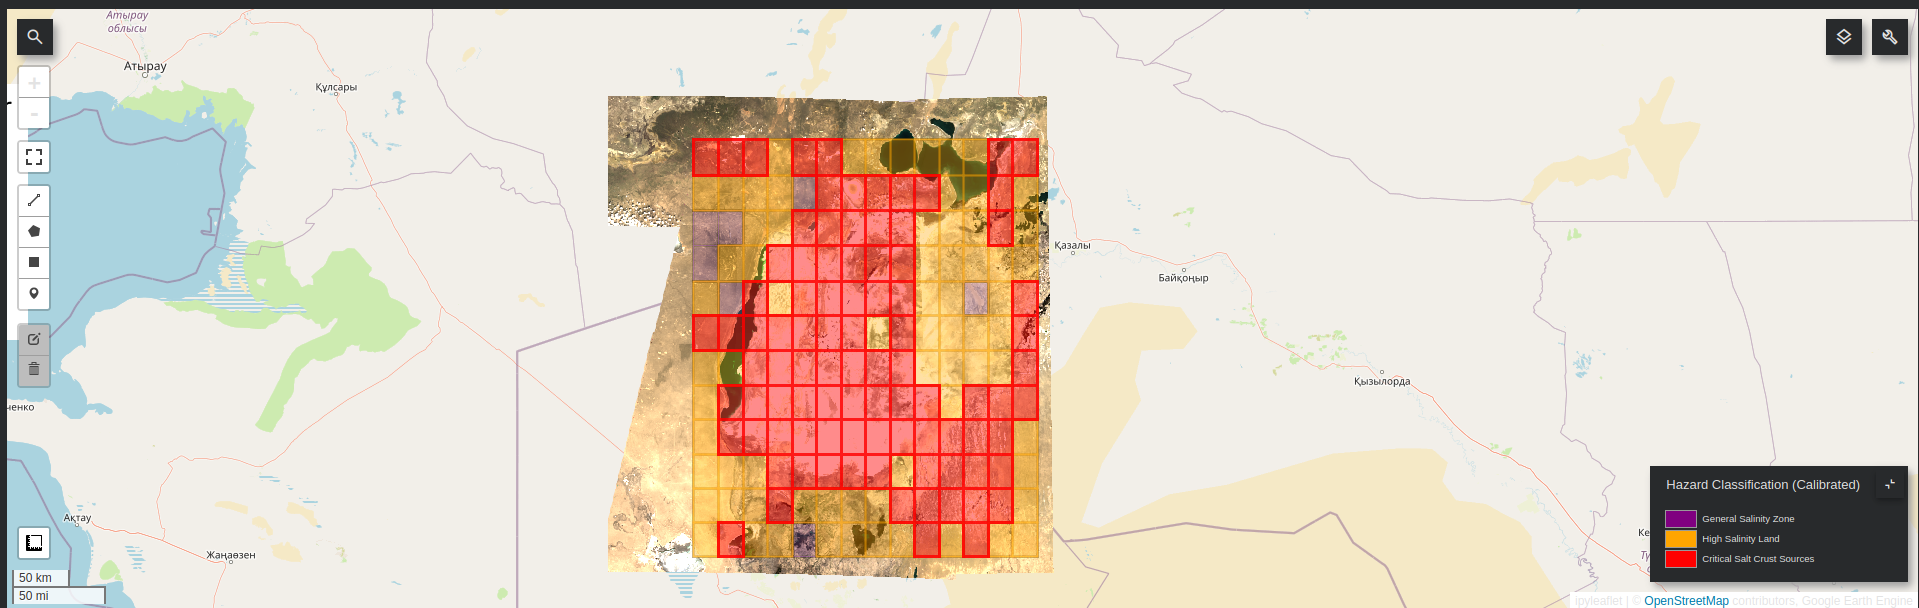

⚠️ Note: If the interactive map above is not displaying correctly (blank space), please refer to the static screenshot provided below for the analyzed results.

In [ ]:
Map_Risk.save('my_aral_map.html')